In [1]:
# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# For saving models
import pickle

In [2]:


                                                            ### PLAN PHASE ###



In [3]:
print('About the company:')
print('')
print('Salifort Motors is a fictional French-based alternative energy vehicle manufacturer. Its global workforce of over 100,000 employees research, design, construct, validate, and distribute electric, solar, algae, and hydrogen-based vehicles. Salifort’s end-to-end vertical integration model has made it a global leader at the intersection of alternative energy and automobiles.    ')

About the company:

Salifort Motors is a fictional French-based alternative energy vehicle manufacturer. Its global workforce of over 100,000 employees research, design, construct, validate, and distribute electric, solar, algae, and hydrogen-based vehicles. Salifort’s end-to-end vertical integration model has made it a global leader at the intersection of alternative energy and automobiles.    


In [4]:
print('Tasks: ')
print('1) The senior leadership team has tasked you with analyzing the data to come up with ideas for how to increase employee retention.')
print('')
print('2) The company is experiencing unexpected employee turnover. Leadership wants to understand why people leave, whether attrition is predictable, and which groups are most at risk.')

Tasks: 
1) The senior leadership team has tasked you with analyzing the data to come up with ideas for how to increase employee retention.

2) The company is experiencing unexpected employee turnover. Leadership wants to understand why people leave, whether attrition is predictable, and which groups are most at risk.


In [5]:


                                                         ### ANALYZE PHASE ###



In [6]:

## 1. Data Cleaning ##


In [7]:
# Import dataset
df = pd.read_csv('HR_capstone_dataset.csv')

# Load first 2 rows of df
df.head(2)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium


In [8]:
# Summary descriptive about the 'df'
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [9]:
# Sneak peek at the df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [10]:
# Rename column for consistency
df = df.rename(columns = {'average_montly_hours' : 'average_monthly_hours',
                          'time_spend_company' : 'tenure',
                          'Work_accident' : 'work_accident',
                          'Department' : 'department'})

In [11]:
# Check for missing / null values
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

In [12]:
# Check for duplicates
print(df.duplicated().sum())
print('')
# Inspect and remove if necessary
df[df.duplicated()].head()

3008



,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [13]:
# Create a new df without duplicates and assign it to new variable
df1 = df.drop_duplicates(keep = 'first')

# Inspect 
print(df1.duplicated().sum())

# Inspect
df.head(1)

0


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low


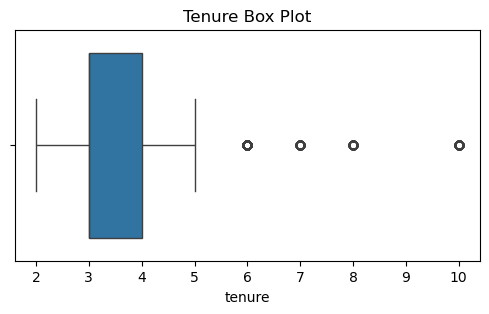

In [14]:
# Plot to see if there is any potential outliers

plt.figure(figsize=(6,3))
plt.title('Tenure Box Plot')
sns.boxplot(x = df1['tenure'])
plt.show()

In [15]:
# 25th (Q1) percentile value in `tenure`                => 25% of the data fall below this value
percentile25 = df1['tenure'].quantile(0.25)

# 75th (Q3) percentile value in `tenure`                => 75% of the data fall below this value
percentile75 = df1['tenure'].quantile(0.75)

# Compute the interquartile (iqr) range in `tenure`
iqr = percentile75 - percentile25

# Compute upper limit and lower limit for non-outlier values in `tenure`
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

# Identify subset of data containing outliers in `tenure`
outliers = df1[(df1['tenure'] > upper_limit) | (df1['tenure'] < lower_limit)]

# Count how many rows in the data contain outliers in `tenure`
print("Number of rows in the data containing outliers in `tenure`:", len(outliers))
print('')
print('***NOTE***: I am try to find values that are greater than 75% quartile and less than 25% quartile. Those values will be considered outliers.')



Lower limit: 1.5
Upper limit: 5.5
Number of rows in the data containing outliers in `tenure`: 824

***NOTE***: I am try to find values that are greater than 75% quartile and less than 25% quartile. Those values will be considered outliers.


In [16]:

## 2. Data Exploration ##


In [17]:
# Understand the data
print(df1['left'].value_counts())
print('')

# To proportion
print(df1['left'].value_counts(normalize = True))
print('')
print('Insight: Roughly 17% of employees left the company.')

left
0    10000
1     1991
Name: count, dtype: int64

left
0    0.833959
1    0.166041
Name: proportion, dtype: float64

Insight: Roughly 17% of employees left the company.


In [18]:


print('*** NOTE *** Above is my interested variable, now I want to see what is the correlation of working status vs number of projects and hours.')



*** NOTE *** Above is my interested variable, now I want to see what is the correlation of working status vs number of projects and hours.


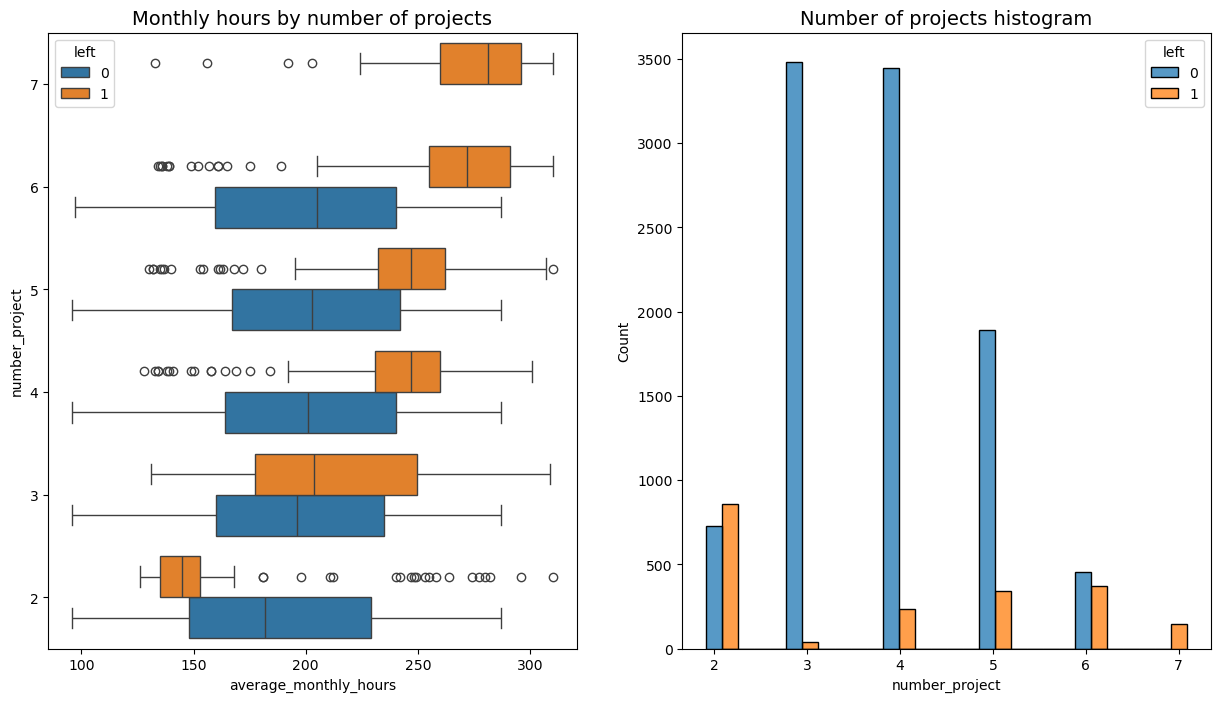

In [19]:
### Monthly hours vs number of project

fig, ax = plt.subplots(1, 2, figsize = (15,8))

# Boxplot showing `average_monthly_hours` distributions for `number_project' for employees who stayed vs left
sns.boxplot(data=df1, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

# Histogram showing distribution of `number_project` for employees who stayed vs left
tenure_stay = df1[df1['left']==0]['number_project']
tenure_left = df1[df1['left']==1]['number_project']
sns.histplot(data=df1, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')

plt.show()

In [20]:
## INSIGHT ##

print('1) Higher number of projects equivalent to longer hours. Those who left, it is reasonable to infer that they probably quit. The folks in the left group likely contributed a lot to the projects they worked in; they might have been the largest contributors to their projects.')
print('')
print('2) All employees who work at 7 projects are left. The median hours for this sector ranging from 255 to 295 hours. Extremely higher compared to the average.')
print('')
print('3) To avoid employee felt overwhelm due to long hours and high number of projects. The optimal number of projects for employees to work on seems to be 3 to 4 and maximum at 5. The ratio of left/stayed is very small for these cohorts. ')
print('')
print('4) Assume, there is 40 hours a week and 50 weeks per year. The average monthly hours for working employee is 166.67 hours (50w * 40hr / 12m). This means, aside from the employees who worked on two projects, every group categories — even those who do not leave the company—worked considerably more hours than this. It seems that employees here are overworked and this could potentially leads to low satisfaction then leave.')



1) Higher number of projects equivalent to longer hours. Those who left, it is reasonable to infer that they probably quit. The folks in the left group likely contributed a lot to the projects they worked in; they might have been the largest contributors to their projects.

2) All employees who work at 7 projects are left. The median hours for this sector ranging from 255 to 295 hours. Extremely higher compared to the average.

3) To avoid employee felt overwhelm due to long hours and high number of projects. The optimal number of projects for employees to work on seems to be 3 to 4 and maximum at 5. The ratio of left/stayed is very small for these cohorts. 

4) Assume, there is 40 hours a week and 50 weeks per year. The average monthly hours for working employee is 166.67 hours (50w * 40hr / 12m). This means, aside from the employees who worked on two projects, every group categories — even those who do not leave the company—worked considerably more hours than this. It seems that empl

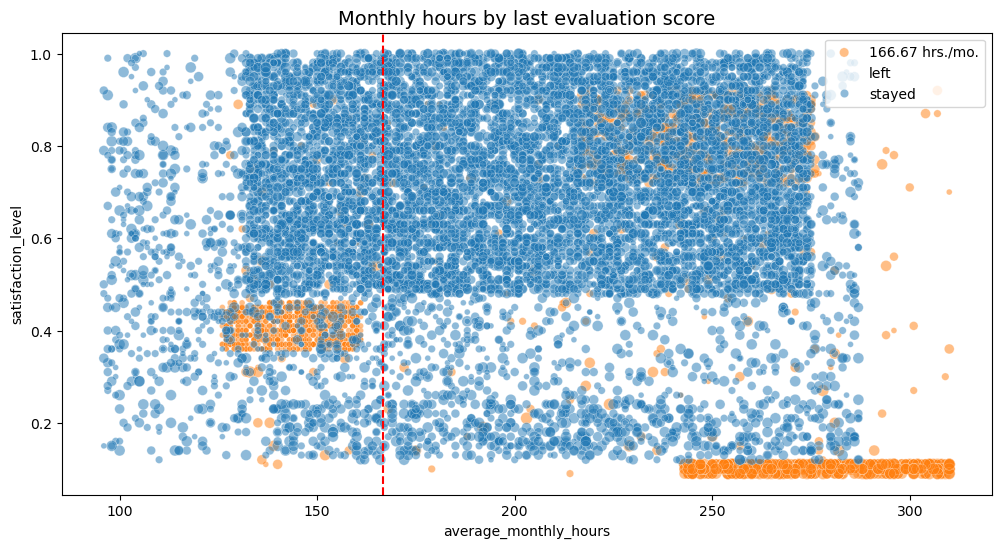

In [21]:
# Based on my assumption, I'm now plotting monthly hours vs satisfaction level to see the correlation

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.5, size = 'number_project')
plt.axvline(x=166.67, color='red', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

In [22]:
## INSIGHT ##

print('1) The first group of employees who left, their satisfaction score at 0.4. I think there are two possible scenarios: 1) They could be fired due to underperform. 2) There is not enough tasks for them to do which also lead to quit due to boredom.')
print('')
print('2) The second group of employees who left is due to overwork and their satisfaction score nearly 0. Where their working hours ranging from 245 ~ 315 hours monthly. That is almost double to the average monthly time')
print('')
print('3) Lastly, 70% of employee who works above the average monthly hours, especially 210-280 hours per month, their satisfaction score at 0.5 to 1 ')


1) The first group of employees who left, their satisfaction score at 0.4. I think there are two possible scenarios: 1) They could be fired due to underperform. 2) There is not enough tasks for them to do which also lead to quit due to boredom.

2) The second group of employees who left is due to overwork and their satisfaction score nearly 0. Where their working hours ranging from 245 ~ 315 hours monthly. That is almost double to the average monthly time

3) Lastly, 70% of employee who works above the average monthly hours, especially 210-280 hours per month, their satisfaction score at 0.5 to 1 


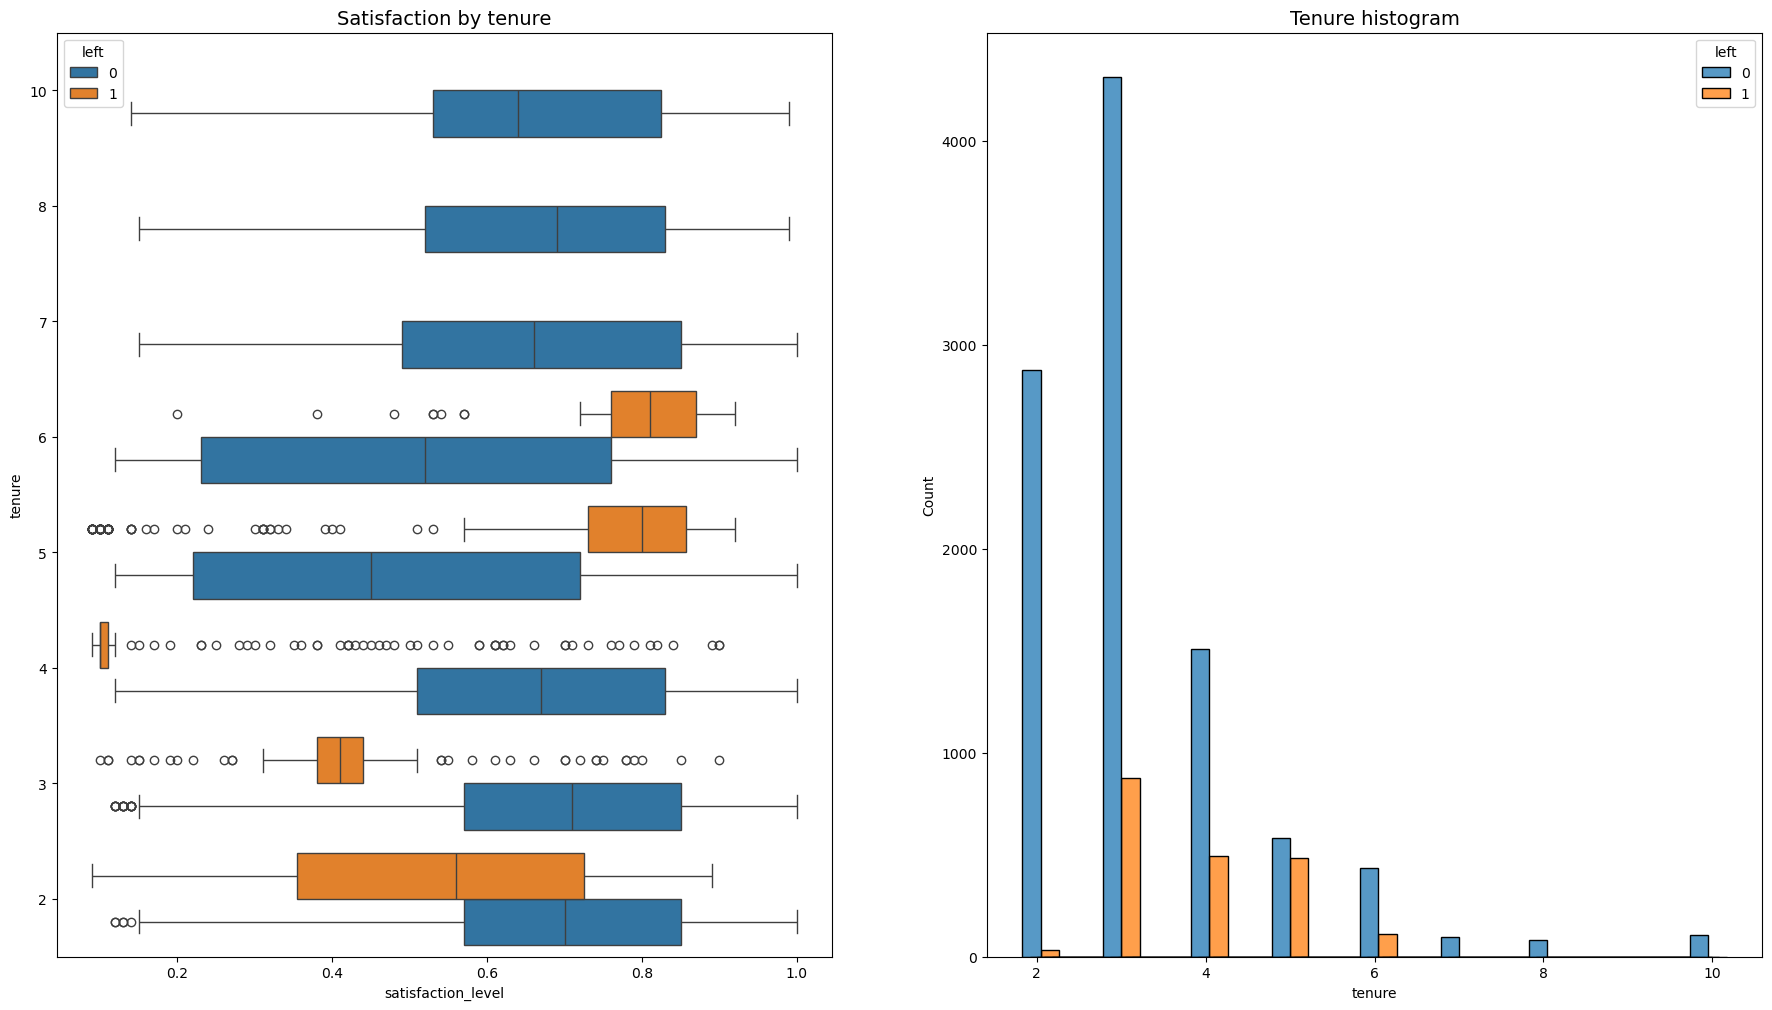

In [23]:
# Satisfaction by tenure
fig, ax = plt.subplots(1, 2, figsize = (22,12))

# Create boxplot showing distributions of `satisfaction_level` by tenure, comparing employees who stayed versus those who left
sns.boxplot(data=df1, x='satisfaction_level', y='tenure', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction by tenure', fontsize='14')

# Create histogram showing distribution of `tenure`, comparing employees who stayed versus those who left
tenure_stay = df1[df1['left']==0]['tenure']
tenure_left = df1[df1['left']==1]['tenure']
sns.histplot(data=df1, x='tenure', hue='left', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Tenure histogram', fontsize='14')

plt.show();

In [24]:
## INSIGHT ##

print('1) Four-year employees who LEFT seem to have an unusually low satisfaction level. It is worth investigating changes to company policy that might have affected people specifically at the four-year mark.')
print('')
print('2) The longest-tenured employees did not leave. Their satisfaction levels aligned with those of newer employees who stayed.')
print('')
print('3) The histogram shows that there are relatively few longer-tenured employees. It is possible that they are the higher-ranking, higher-paid employees.')



1) Four-year employees who LEFT seem to have an unusually low satisfaction level. It is worth investigating changes to company policy that might have affected people specifically at the four-year mark.

2) The longest-tenured employees did not leave. Their satisfaction levels aligned with those of newer employees who stayed.

3) The histogram shows that there are relatively few longer-tenured employees. It is possible that they are the higher-ranking, higher-paid employees.


In [25]:
# Calculate mean and median satisfaction scores of employees who left and those who stayed
print(df1.groupby('left')['satisfaction_level'].agg(['mean', 'median']))
print('')
print('As I expected, the mean and median satisfaction scores of employees who left are lower than those of employees who stayed. Interestingly, among employees who stayed.')



          mean  median
left                  
0     0.667365    0.69
1     0.440271    0.41

As I expected, the mean and median satisfaction scores of employees who left are lower than those of employees who stayed. Interestingly, among employees who stayed.


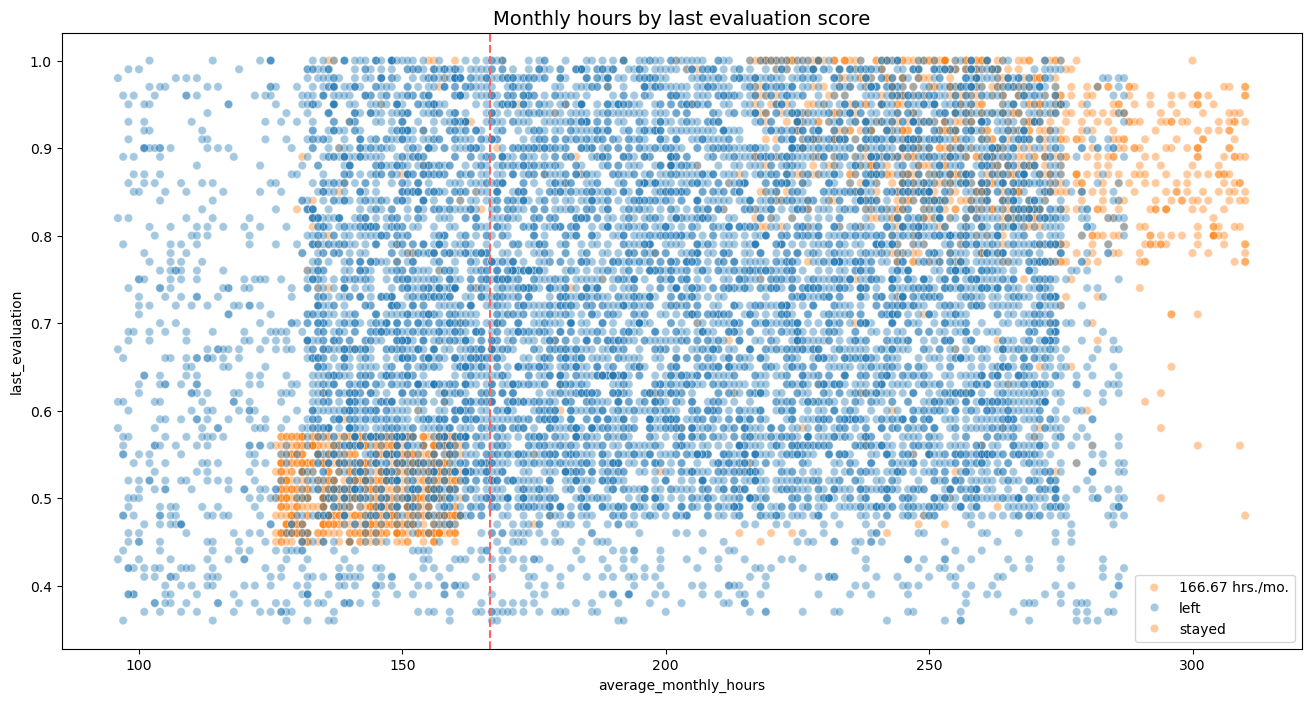

In [26]:
# Create scatterplot of `average_monthly_hours` versus `last_evaluation`
plt.figure(figsize=(16, 8))
sns.scatterplot(data=df1, x='average_monthly_hours', y='last_evaluation', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

In [27]:
## INSIGHT ##

print('1) The scatterplot indicates two groups of employees who left: overworked employees who performed very well and employees who worked slightly under the nominal monthly average of 166.67 hours with lower evaluation scores.')
print('')
print('2) There seems to be a correlation between hours worked and evaluation score.')
print('')
print('3) Most of the employees in this company work well over 167 hours per month. This insight leads me to another question: If an employee work considerately longer hours, will they be promoted or their salary increasing?')

1) The scatterplot indicates two groups of employees who left: overworked employees who performed very well and employees who worked slightly under the nominal monthly average of 166.67 hours with lower evaluation scores.

2) There seems to be a correlation between hours worked and evaluation score.

3) Most of the employees in this company work well over 167 hours per month. This insight leads me to another question: If an employee work considerately longer hours, will they be promoted or their salary increasing?


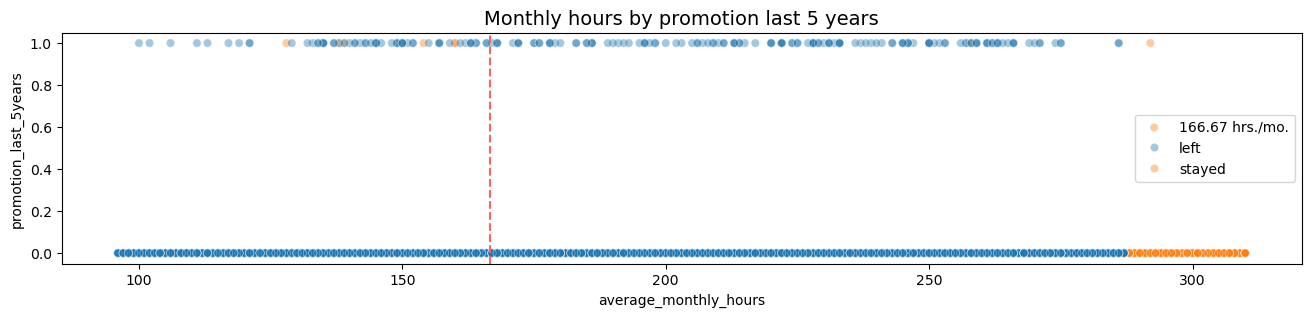

In [28]:
# Plot to examine relationship between average_monthly_hours and promotion_last_5years
plt.figure(figsize=(16, 3))
sns.scatterplot(data=df1, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by promotion last 5 years', fontsize='14');


In [29]:
## INSIGHT ##

print('1) Very few people were promoted within the last five years. Despite being promoted but their average monthly hours is below the median mark. Why are they being promoted while other employees works extremely hard but barely got their name listed on promotion list. ')
print('')
print('2) Despite being promoted, some still leaving the company. This could be due to the promotion package is not quite compelling?')
print('')
print('3) Employee who left works extremely longer hours.')
print('')
"""
*** NOTE: My next guess is that, will one department having significant impact versus the other one? For instance, one department could have higher chance on employee's quitting.

"""


1) Very few people were promoted within the last five years. Despite being promoted but their average monthly hours is below the median mark. Why are they being promoted while other employees works extremely hard but barely got their name listed on promotion list. 

2) Despite being promoted, some still leaving the company. This could be due to the promotion package is not quite compelling?

3) Employee who left works extremely longer hours.



"\n*** NOTE: My next guess is that, will one department having significant impact versus the other one? For instance, one department could have higher chance on employee's quitting.\n\n"

In [30]:
# Display counts for each department
df1["department"].value_counts()


department
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

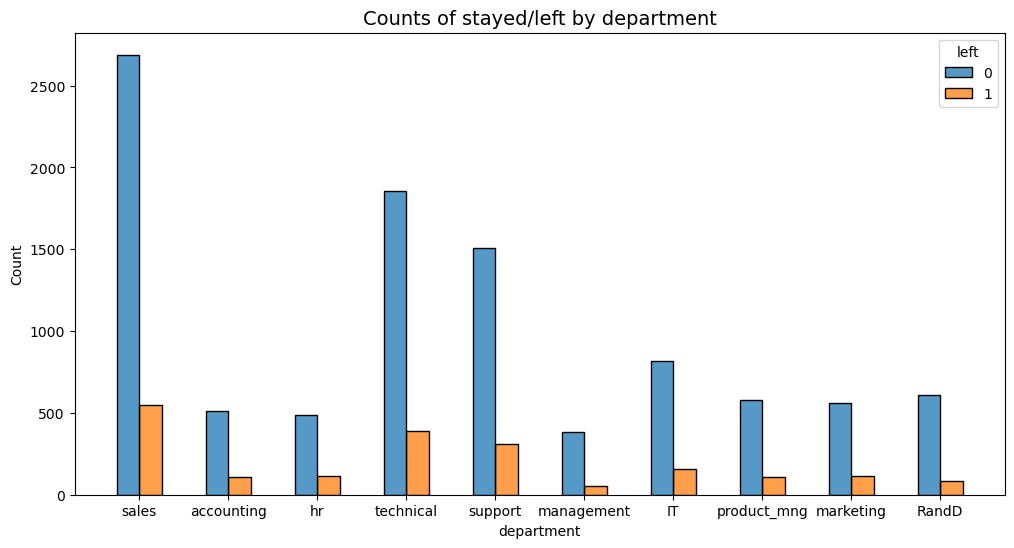

In [31]:
# Create stacked histogram to compare department distribution of employees who left to that of employees who didn't
plt.figure(figsize=(12,6))
sns.histplot(data=df1, x='department', hue='left', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.title('Counts of stayed/left by department', fontsize=14);


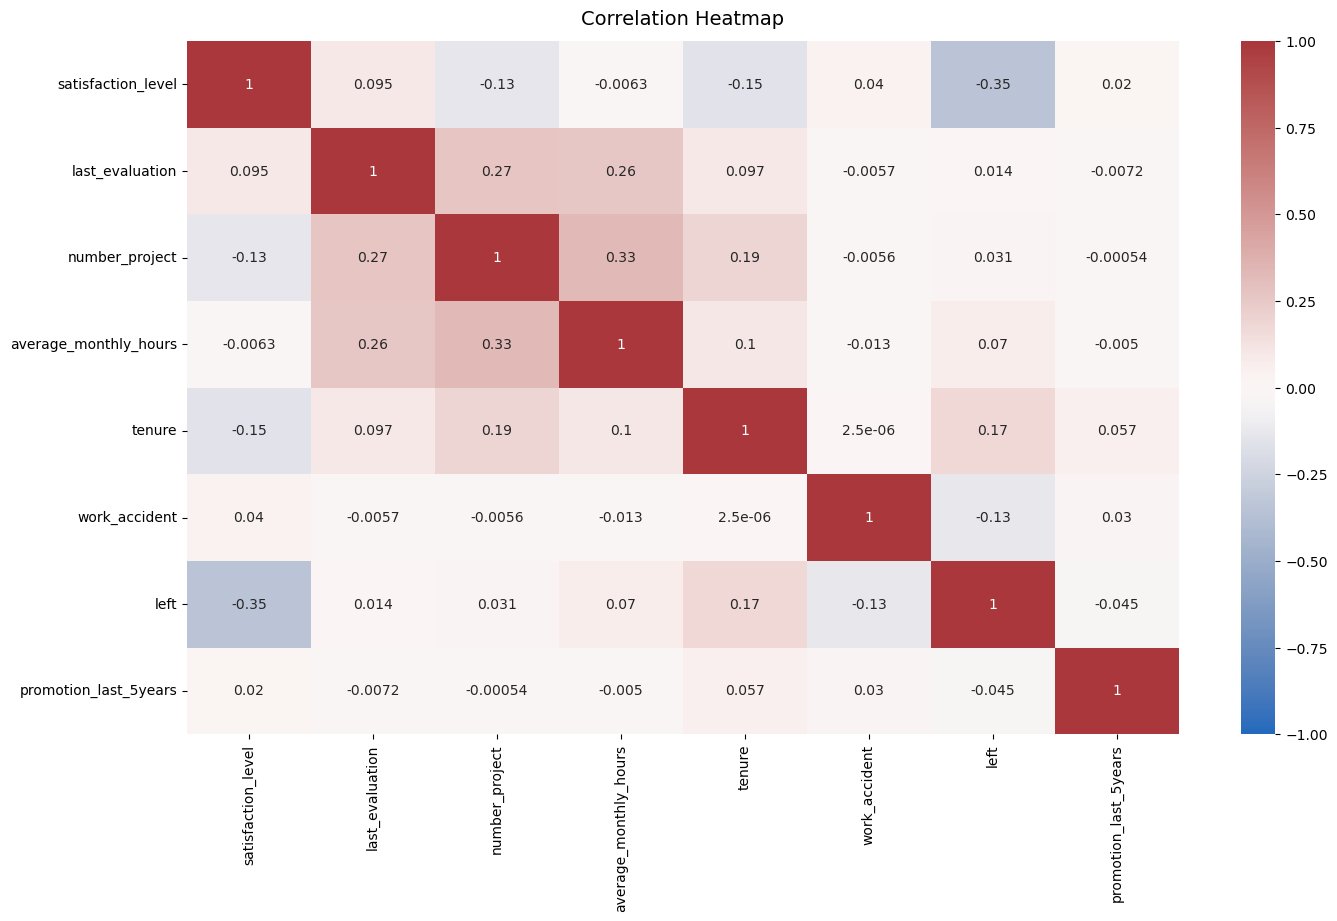

In [32]:
# Plot a correlation heatmap
plt.figure(figsize=(16, 9))
ax = sns.heatmap(
    df1.select_dtypes(include=['float64', 'int64']).corr(),
    vmin=-1,
    vmax=1,
    annot=True,
    cmap="vlag"
)
ax.set_title("Correlation Heatmap", fontsize=14, pad=12)
plt.show()

In [33]:
'''
NOTICEABLE ATTRIBUTES FROM HEATMAP MATRIX:
'''

print('The correlation heatmap confirms that attributes like:')
print('1) The number of projects')
print('2) Average monthly hours')
print('3) Evaluation scores all have some positive correlation with each other')
print('4) Though, whether an employee leaves is negatively correlated with their satisfaction level.')

The correlation heatmap confirms that attributes like:
1) The number of projects
2) Average monthly hours
3) Evaluation scores all have some positive correlation with each other
4) Though, whether an employee leaves is negatively correlated with their satisfaction level.


In [34]:

## 3. Construct A Model  ##


In [35]:
# Drop duplicates
df1 = df.drop_duplicates(keep='first')

print(df1.shape)
df1.head()

(11991, 10)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [36]:
# Encode salary ordinally
df_enc = df1.copy()
df_enc['salary'] = (
    df_enc['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes
)

# Dummy encode department
df_enc = pd.get_dummies(df_enc, drop_first=False)

# Compute tenure outlier bounds
percentile25 = df1['tenure'].quantile(0.25)
percentile75 = df1['tenure'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

print(f"Tenure outlier bounds: [{lower_limit}, {upper_limit}]")
df_enc.head()

Tenure outlier bounds: [1.5, 5.5]


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


In [37]:
# Helper Function


# Function to extract CV scores from GridSearchCV result
def make_results(model_name, model_object, metric):
    """Extract CV scores from GridSearchCV result."""
    metric_dict = {
        'auc': 'mean_test_roc_auc',
        'precision': 'mean_test_precision',
        'recall': 'mean_test_recall',
        'f1': 'mean_test_f1',
        'accuracy': 'mean_test_accuracy'
    }
    cv_results = pd.DataFrame(model_object.cv_results_)
    best = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]
    return pd.DataFrame({
        'model': [model_name],
        'precision': [best.mean_test_precision],
        'recall': [best.mean_test_recall],
        'F1': [best.mean_test_f1],
        'accuracy': [best.mean_test_accuracy],
        'auc': [best.mean_test_roc_auc]
    })


def get_scores(model_name, model, X_test_data, y_test_data):
    """Generate test scores from best estimator."""
    preds = model.best_estimator_.predict(X_test_data)
    return pd.DataFrame({
        'model': [model_name],
        'precision': [precision_score(y_test_data, preds)],
        'recall': [recall_score(y_test_data, preds)],
        'f1': [f1_score(y_test_data, preds)],
        'accuracy': [accuracy_score(y_test_data, preds)],
        'AUC': [roc_auc_score(y_test_data, preds)]
    })

In [38]:
# Train/Test Split

# Isolate target variable and features
y = df_enc['left']
X = df_enc.drop('left', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)
print(X_train.shape, X_test.shape)

(8993, 18) (2998, 18)


In [39]:

                                    ### Decision Tree / Random Forest ###


In [40]:
# Round 1
tree = DecisionTreeClassifier(random_state=0)

cv_params = {
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [2, 5, 1],
    'min_samples_split': [2, 4, 6]
}
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

tree1 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')
tree1.fit(X_train, y_train)

print("Best params:", tree1.best_params_)
print("Best AUC (CV):", tree1.best_score_)

Best params: {'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best AUC (CV): 0.969819392792457


In [41]:
# Istantitate randome forest
rf = RandomForestClassifier(random_state=0)

cv_params = {
    'max_depth': [3, 5, None],
    'max_features': [1.0],
    'max_samples': [0.7, 1.0],
    'min_samples_leaf': [1, 2, 3],
    'min_samples_split': [2, 3, 4],
    'n_estimators': [300, 500],
}
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


# Run grid search — this may take ~10 minutes
rf1 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')
rf1.fit(X_train, y_train)

print("Best params:", rf1.best_params_)
print("Best AUC (CV):", rf1.best_score_)

Best params: {'max_depth': 5, 'max_features': 1.0, 'max_samples': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 500}
Best AUC (CV): 0.9804250949807172


In [42]:
# Compare CV Results

tree1_cv_results = make_results('decision tree1 cv', tree1, 'auc')
rf1_cv_results   = make_results('random forest1 cv', rf1, 'auc')

print(tree1_cv_results.to_string(index=False))
print(rf1_cv_results.to_string(index=False))

            model  precision   recall       F1  accuracy      auc
decision tree1 cv   0.914552 0.916949 0.915707  0.971978 0.969819
            model  precision   recall       F1  accuracy      auc
random forest1 cv   0.950023 0.915614 0.932467  0.977983 0.980425


In [43]:
# Test Scores

rf1_test_scores = get_scores('random forest1 test', rf1, X_test, y_test)
print(rf1_test_scores.to_string(index=False))

              model  precision   recall       f1  accuracy      AUC
random forest1 test   0.964211 0.919679 0.941418  0.980987 0.956439


In [44]:
# Round 2 - Engineer overwork feature

# Drop satisfaction_level — may not be available in real deployment
df2 = df_enc.drop('satisfaction_level', axis=1).copy()

# Create binary overworked feature: 1 if working more than 175 hrs/month
df2['overworked'] = (df2['average_monthly_hours'] > 175).astype(int)

# Drop original hours column since it's now replaced by overworked
df2 = df2.drop('average_monthly_hours', axis=1)

print(df2['overworked'].value_counts())
df2.head()

overworked
1    7630
0    4361
Name: count, dtype: int64


,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,overworked
0,0.53,2,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0
1,0.86,5,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False,1
2,0.88,7,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False,1
3,0.87,5,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False,1
4,0.52,2,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0


In [45]:
# Train/Test Split 

# Isolate target variable and features for Round 2
y = df2['left']
X = df2.drop('left', axis=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)
print(X_train.shape, X_test.shape)

(8993, 17) (2998, 17)


In [46]:
# Round 2


# Instantiate decision tree
tree = DecisionTreeClassifier(random_state=0)

# Define hyperparameters to search
cv_params = {
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [2, 5, 1],
    'min_samples_split': [2, 4, 6]
}
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


# Run grid search
tree2 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')
tree2.fit(X_train, y_train)

print("Best params:", tree2.best_params_)
print("Best AUC (CV):", tree2.best_score_)

Best params: {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 6}
Best AUC (CV): 0.9586752505340426


In [47]:
# Instantiate random forest
rf = RandomForestClassifier(random_state=0)

# Define hyperparameters to search
cv_params = {
    'max_depth': [3, 5, None],
    'max_features': [1.0],
    'max_samples': [0.7, 1.0],
    'min_samples_leaf': [1, 2, 3],
    'min_samples_split': [2, 3, 4],
    'n_estimators': [300, 500],
}
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Run grid search 
rf2 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')
rf2.fit(X_train, y_train)  # takes ~7 min

print("Best params:", rf2.best_params_)
print("Best AUC (CV):", rf2.best_score_)

Best params: {'max_depth': 5, 'max_features': 1.0, 'max_samples': 0.7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best AUC (CV): 0.9648089938973397


In [48]:
# Compare cross-validation scores for both Round 2 models
tree2_cv_results = make_results('decision tree2 cv', tree2, 'auc')
rf2_cv_results   = make_results('random forest2 cv', rf2, 'auc')

print(tree2_cv_results.to_string(index=False))
print(rf2_cv_results.to_string(index=False))

            model  precision   recall       F1  accuracy      auc
decision tree2 cv   0.856693 0.903553 0.878882  0.958523 0.958675
            model  precision   recall       F1  accuracy      auc
random forest2 cv   0.866758 0.878754 0.872407  0.957411 0.964809


              model  precision   recall     f1  accuracy      AUC
random forest2 test   0.870406 0.903614 0.8867  0.961641 0.938407


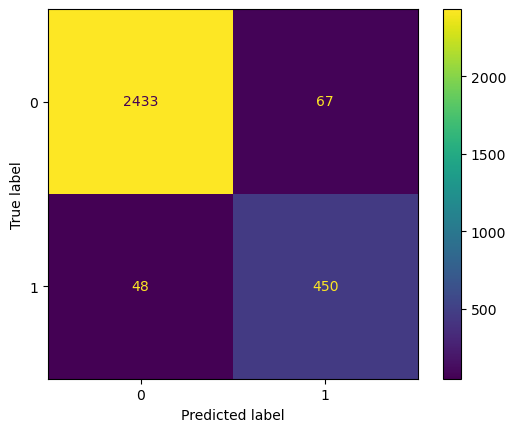

In [49]:
# ROund 2 - Test score + confusion matrix

rf2_test_scores = get_scores('random forest2 test', rf2, X_test, y_test)
print(rf2_test_scores.to_string(index=False))

# Confusion matrix
preds = rf2.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, preds, labels=rf2.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf2.classes_).plot(values_format='')
plt.show()

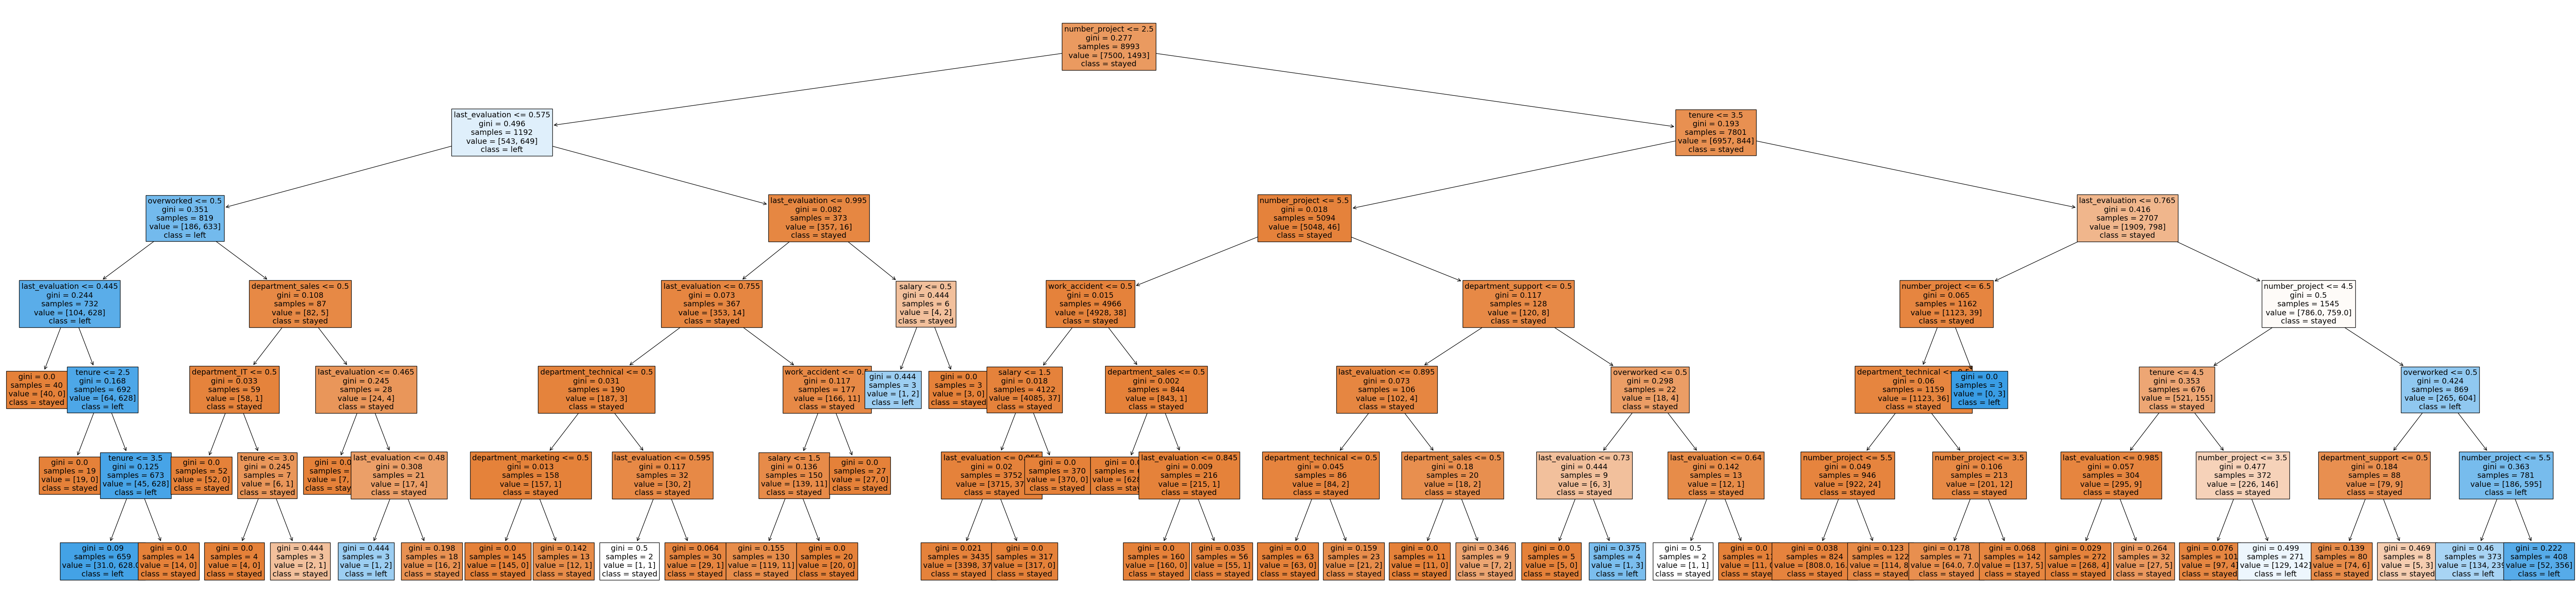

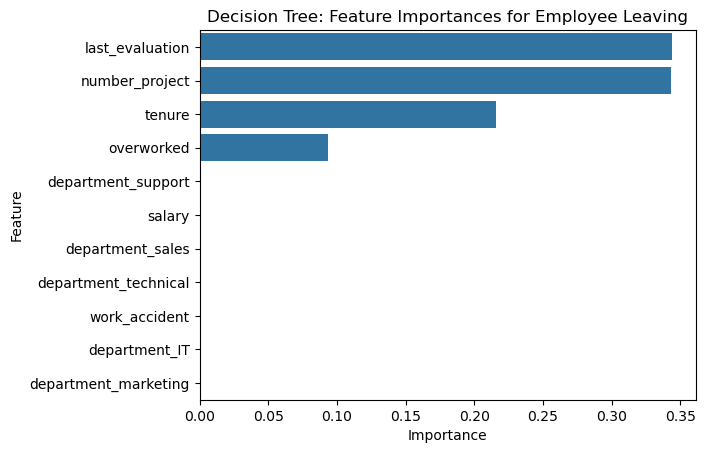

In [50]:
# Plot tree
plt.figure(figsize=(85, 20))
plot_tree(tree2.best_estimator_, max_depth=6, fontsize=14,
          feature_names=X.columns, class_names={0: 'stayed', 1: 'left'}, filled=True)
plt.show()

# Feature importances
tree2_importances = pd.DataFrame(
    tree2.best_estimator_.feature_importances_,
    columns=['gini_importance'],
    index=X.columns
).sort_values(by='gini_importance', ascending=False)
tree2_importances = tree2_importances[tree2_importances['gini_importance'] != 0]

sns.barplot(data=tree2_importances, x='gini_importance', y=tree2_importances.index, orient='h')
plt.title("Decision Tree: Feature Importances for Employee Leaving", fontsize=12)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.show()

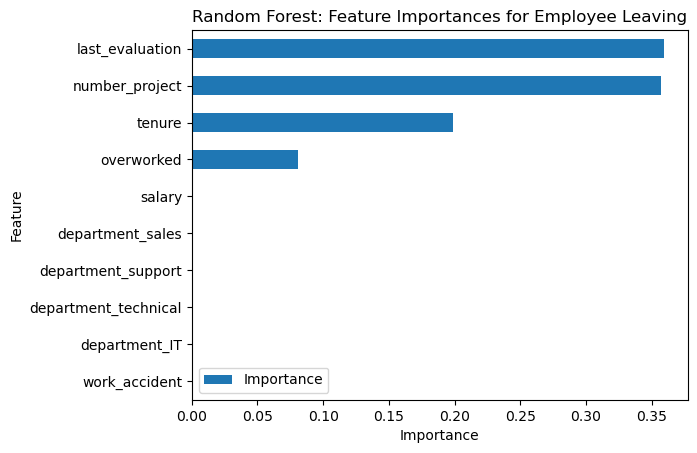

In [51]:
feat_impt = rf2.best_estimator_.feature_importances_
ind = np.argpartition(feat_impt, -10)[-10:]
feat = X.columns[ind]

y_df = pd.DataFrame({"Feature": feat, "Importance": feat_impt[ind]})
y_sort_df = y_df.sort_values("Importance")

fig, ax = plt.subplots()
y_sort_df.plot(kind='barh', ax=ax, x='Feature', y='Importance')
ax.set_title("Random Forest: Feature Importances for Employee Leaving", fontsize=12)
ax.set_ylabel("Feature")
ax.set_xlabel("Importance")
plt.show()

In [52]:


                                                            ### EXECUTE PHASE ###



In [105]:
### INSIGHTS SUMMARY FROM MY ANALYSIS ###

print('INSIGHTS SUMMARY:')
print('')
print('=== Key Findings ===')
print('- Employees are likely leaving due to poor management and burnout.')
print('- Leaving is tied to longer working hours, many projects, and lower satisfaction levels.')
print('- Employees with 6+ years tenure tend to stay; dissatisfaction peaks around 4 years.')
print('- High evaluation scores are disproportionately tied to excessive working hours.')
print('')
print('=== Recommendations ===')
print('- Cap the number of projects employees can work on to prevent overload.')
print('- Consider promoting employees who have been with the company for at least 4 years.')
print('- Reward employees for long hours, or reduce excessive workload expectations.')
print("- Clarify overtime pay policies and make workload/time-off expectations explicit.")
print('- Reserve high evaluation scores proportionately, not only for 200+ hr/month workers.')
print('- Hold company-wide discussions to address work culture across departments.')

INSIGHTS SUMMARY:

=== Key Findings ===
- Employees are likely leaving due to poor management and burnout.
- Leaving is tied to longer working hours, many projects, and lower satisfaction levels.
- Employees with 6+ years tenure tend to stay; dissatisfaction peaks around 4 years.
- High evaluation scores are disproportionately tied to excessive working hours.

=== Recommendations ===
- Cap the number of projects employees can work on to prevent overload.
- Consider promoting employees who have been with the company for at least 4 years.
- Reward employees for long hours, or reduce excessive workload expectations.
- Clarify overtime pay policies and make workload/time-off expectations explicit.
- Reserve high evaluation scores proportionately, not only for 200+ hr/month workers.
- Hold company-wide discussions to address work culture across departments.
